In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import tqdm
import random
import math
from scipy.interpolate import griddata
np.random.seed(0)

In [2]:
def gird(xmin, xmax, ymin, ymax):
  xstep=(xmax-xmin)/50
  ystep=(ymax-ymin)/50
  y=ymin
  Cord=[]
  #print(x, y)
  while y<ymax or y==ymax:
    x=xmin
    while x<xmax or x==xmax:
      #print(x, y)
      Point=[]
      Point.append(x)
      Point.append(y)
      Cord.append(Point)
      x+=xstep
    y+=ystep
  return Cord

In [3]:
def func(x, y):
  return np.exp(-(x**2+y**2)/2)

In [4]:
gd=gird(-1, 1, -1, 1)

In [5]:

n=len(gd)-1
#print('n', n)
k=0
U=[]
#print('gd', gd)
while k<n or k==n:
  u=func(gd[k][0], gd[k][1])
  U.append(u)
  #print('k', k)
  k+=1
#print('U', U)
#len(gd)

In [6]:
X=[]
Y=[]
i=0
while i<n or i==n:
  X.append(gd[i][0])
  Y.append(gd[i][1])
  i+=1


In [7]:
Xn=np.array(X)
Yn=np.array(Y)
Xnn, Ynn =np.meshgrid(Xn, Yn)
Unn=func(Xnn, Ynn)

/tmp/ipykernel_743/2599208629.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(


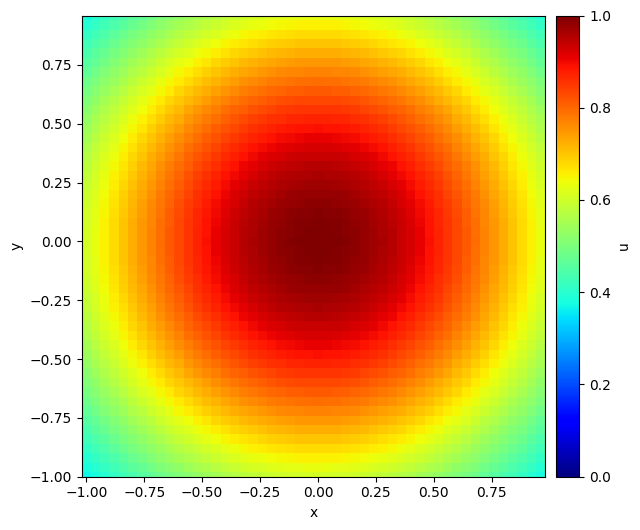

In [8]:

# 1. Двумерная карта в стиле снимка
fig, ax = plt.subplots(figsize=(6.6, 5.4))

pcm = ax.pcolormesh(
    Xnn, Ynn, Unn,
    cmap="jet",
    shading="auto",
    vmin=0,

)



cb = fig.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label("u")

ax.set_xlabel("x")
ax.set_ylabel("y")
#ax.set_xlim(xi.min(), xi.max())
#ax.set_ylim(yi.min(), yi.max())
ax.set_aspect("auto")
fig.tight_layout()
plt.show()



In [9]:

def random_asymmetric_grid(n_points=1000, xlim=(-2.0, 3.5), ylim=(-1.0, 2.0), seed=0):
    """Случайная несимметричная сетка: независимые x, y из разных отрезков."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(xlim[0], xlim[1], size=n_points)
    y = rng.uniform(ylim[0], ylim[1], size=n_points)
    return x, y

In [10]:
xlim = (-1.0, 1.0)
ylim = (-1.0, 1.0)
n_points = 1000


x, y = random_asymmetric_grid(n_points=n_points, xlim=xlim, ylim=ylim, seed=0)
u = func(x, y)

print(f"Число узлов: {n_points}")
print(f"x in [{x.min():.3f}, {x.max():.3f}]")
print(f"y in [{y.min():.3f}, {y.max():.3f}]")
print(f"u in [{u.min():.3e}, {u.max():.3e}]")

Число узлов: 1000
x in [-1.000, 0.999]
y in [-0.996, 0.996]
u in [3.728e-01, 9.994e-01]


In [11]:
n_view = 200
xi = np.linspace(xlim[0], xlim[1], n_view)
yi = np.linspace(ylim[0], ylim[1], n_view)
X, Y = np.meshgrid(xi, yi)

U = griddata(np.column_stack([x, y]), u, (X, Y), method="linear")
U_near = griddata(np.column_stack([x, y]), u, (X, Y), method="nearest")
U = np.where(np.isnan(U), U_near, U)

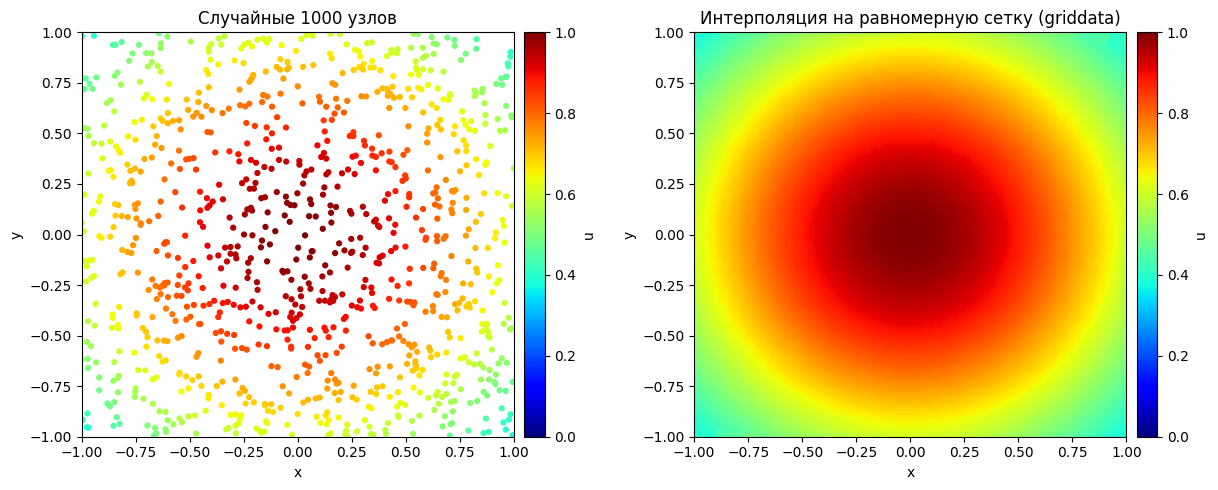

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.0))

sc = axes[0].scatter(x, y, c=u, cmap="jet", s=12, vmin=0.0, vmax=1.0)
cb0 = fig.colorbar(sc, ax=axes[0], pad=0.02)
cb0.set_label("u")
axes[0].set_title(f"Случайные {n_points} узлов")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_xlim(*xlim)
axes[0].set_ylim(*ylim)
axes[0].set_aspect("auto")

pcm = axes[1].pcolormesh(X, Y, U, cmap="jet", shading="auto", vmin=0.0, vmax=1.0)
cb1 = fig.colorbar(pcm, ax=axes[1], pad=0.02)
cb1.set_label("u")
axes[1].set_title("Интерполяция на равномерную сетку (griddata)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_xlim(*xlim)
axes[1].set_ylim(*ylim)
axes[1].set_aspect("auto")

fig.tight_layout()
plt.show()

In [13]:
class PINNModel(nn.Module):
    def __init__(
        self,
        input_size=2,
        nnodes=5,
        output_size=1,
        nhlayers=3,
        activation=nn.Tanh(),
    ):
        super().__init__()
        self.activation = activation
        self.nhlayers = nhlayers
        self.nnodes = nnodes

        self.dense0 = nn.Linear(input_size, nnodes)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(nnodes, nnodes) for _ in range(nhlayers)]
        )
        self.output_layer = nn.Linear(nnodes, output_size)

    def forward(self, x):
        if x.dtype == torch.float64:
            x = x.float()
        x = self.activation(self.dense0(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)
        x = self.activation(x)
        return x

model = PINNModel(input_size=2, nnodes=5, output_size=1, nhlayers=3, activation=nn.Tanh())
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Число обучаемых параметров: {n_params}")

PINNModel(
  (activation): Tanh()
  (dense0): Linear(in_features=2, out_features=5, bias=True)
  (hidden_layers): ModuleList(
    (0-2): 3 x Linear(in_features=5, out_features=5, bias=True)
  )
  (output_layer): Linear(in_features=5, out_features=1, bias=True)
)
Число обучаемых параметров: 111


In [14]:
x_rand = torch.randn(8, 2)
y_rand = model(x_rand)
print("Вход:", tuple(x_rand.shape), x_rand.dtype)
print("Выход:", tuple(y_rand.shape), y_rand.dtype)
print(y_rand.detach().numpy().ravel())
assert y_rand.shape == (8, 1)
assert torch.all(y_rand > -1) and torch.all(y_rand < 1)
print("Проверка пройдена: форма (N, 1), значения в (-1, 1).")

Вход: (8, 2) torch.float32
Выход: (8, 1) torch.float32
[0.59371537 0.58763415 0.5974156  0.59498584 0.61066514 0.5904073
 0.6166482  0.61692524]
Проверка пройдена: форма (N, 1), значения в (-1, 1).


In [15]:
xy_np = np.column_stack([x.flatten(), y.flatten()]).astype(np.float32)
u_np = u.flatten()[:, None].astype(np.float32)

xy_train = torch.from_numpy(xy_np)
u_train = torch.from_numpy(u_np)

print("xy_train:", tuple(xy_train.shape), xy_train.dtype)
print("u_train:", tuple(u_train.shape), u_train.dtype)

xy_train: (1000, 2) torch.float32
u_train: (1000, 1) torch.float32


In [16]:
class TrainParams:
    def __init__(self, numEpoch=80, xy=None, u=None):
        self.numEpoch = numEpoch
        self.xy = xy
        self.u = u


def copyLoss(model, trp):
    pred = model(trp.xy)
    return torch.mean((pred - trp.u) ** 2)

def make_model(seed=0):
    torch.manual_seed(seed)
    return PINNModel()


def train_optimizer(model, opt, trp, scheduler=None, use_closure=False, save_path=None):
    hist_loss = []
    hist_lr = []
    pbar = tqdm.tqdm(range(trp.numEpoch), desc="Training Progress")
    t0 = time.time()
    for step in pbar:
        def closure():
            opt.zero_grad()
            loss = copyLoss(model, trp)
            loss.backward()
            return loss

        if use_closure:
            loss_t = opt.step(closure)
            current_loss = float(loss_t.detach())
        else:
            loss_t = closure()
            opt.step()
            current_loss = float(loss_t.detach())

        if scheduler is not None:
            scheduler.step()

        hist_loss.append(current_loss)
        hist_lr.append(float(opt.param_groups[0]["lr"]))
        if step % 2 == 0:
            pbar.set_description("Step: %d | Loss: %.10f" % (step, current_loss))

    if save_path is not None:
        torch.save(model.state_dict(), save_path)
    print("Обучение заняло %.1f с. Итоговый Loss = %.6e" % (time.time() - t0, hist_loss[-1]))
    return hist_loss, hist_lr



In [17]:
trp_lbfgs = TrainParams(numEpoch=80, xy=xy_train, u=u_train)
trp_fo = TrainParams(numEpoch=2000, xy=xy_train, u=u_train)
trp_sgd = TrainParams(numEpoch=2000, xy=xy_train, u=u_train)
histories = {}
final_models = {}

In [18]:
model_lbfgs = make_model(seed=0)
opt_lbfgs = torch.optim.LBFGS(
    model_lbfgs.parameters(),
    lr=1.0,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe",
)
hist_lbfgs, _ = train_optimizer(
    model_lbfgs, opt_lbfgs, trp_lbfgs,
    use_closure=True, save_path="pinn_model_lbfgs",
)
histories["LBFGS"] = hist_lbfgs
final_models["LBFGS"] = model_lbfgs

Step: 78 | Loss: 0.0000034985: 100%|██████████| 80/80 [00:02<00:00, 31.61it/s] 

Обучение заняло 2.5 с. Итоговый Loss = 3.498514e-06


In [19]:
model_adam = make_model(seed=0)
opt_adam = torch.optim.Adam(model_adam.parameters(), lr=1e-2)
hist_adam, _ = train_optimizer(
    model_adam, opt_adam, trp_fo,
    use_closure=False, save_path="pinn_model_adam",
)
histories["Adam"] = hist_adam
final_models["Adam"] = model_adam

Step: 1998 | Loss: 0.0000276822: 100%|██████████| 2000/2000 [00:06<00:00, 307.95it/s]

Обучение заняло 6.5 с. Итоговый Loss = 2.765997e-05


In [20]:
model_sgd = make_model(seed=0)
lr0 = 0.1
opt_sgd = torch.optim.SGD(model_sgd.parameters(), lr=lr0, momentum=0.9)

def lr_lambda(epoch):
    return 0.99 ** epoch

scheduler = torch.optim.lr_scheduler.LambdaLR(opt_sgd, lr_lambda=lr_lambda)


hist_sgd, hist_lr_sgd = train_optimizer(
    model_sgd, opt_sgd, trp_sgd,
    scheduler=scheduler, use_closure=False,
    save_path="pinn_model_sgd_lambda",
)
histories["SGD+LambdaR"] = hist_sgd
final_models["SGD+LambdaR"] = model_sgd

Step: 1998 | Loss: 0.0953133777: 100%|██████████| 2000/2000 [00:04<00:00, 414.63it/s]

Обучение заняло 4.8 с. Итоговый Loss = 9.531338e-02


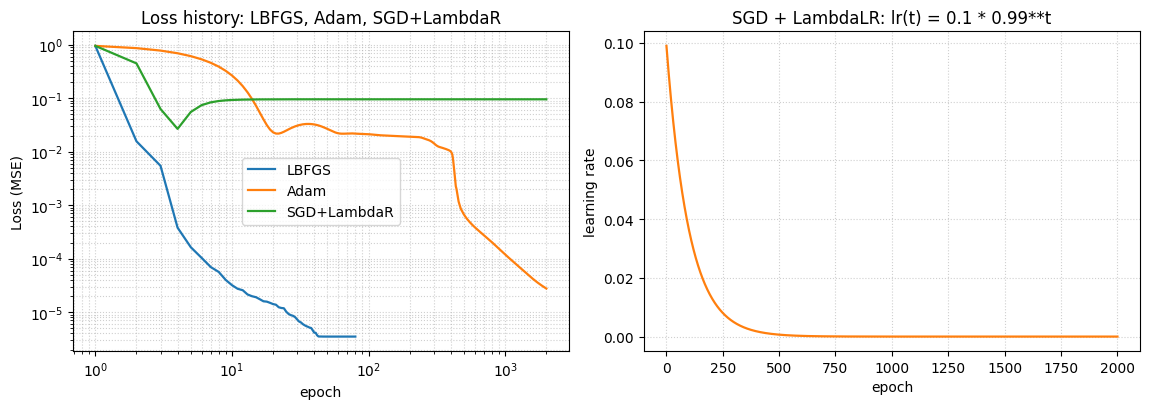

Final Loss:
  LBFGS     3.498514e-06  (epochs: 80)
  Adam      2.765997e-05  (epochs: 2000)
  SGD+LambdaR  9.531338e-02  (epochs: 2000)


In [21]:
fig, ax = plt.subplots(1, 2, figsize=(11.6, 4.2))
for name, hist in histories.items():
    ax[0].plot(np.arange(1, len(hist) + 1), hist, lw=1.6, label=name)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("Loss (MSE)")
ax[0].set_title("Loss history: LBFGS, Adam, SGD+LambdaR")
ax[0].grid(True, which="both", ls=":", alpha=0.6)
ax[0].legend()
ax[1].plot(np.arange(1, len(hist_sgd) + 1), hist_lr_sgd, color="tab:orange", lw=1.6)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("learning rate")
ax[1].set_title("SGD + LambdaLR: lr(t) = 0.1 * 0.99**t")
ax[1].grid(True, ls=":", alpha=0.6)
fig.tight_layout()
plt.show()

print("Final Loss:")
for name, hist in histories.items():
    print("  %-8s  %.6e  (epochs: %d)" % (name, hist[-1], len(hist)))

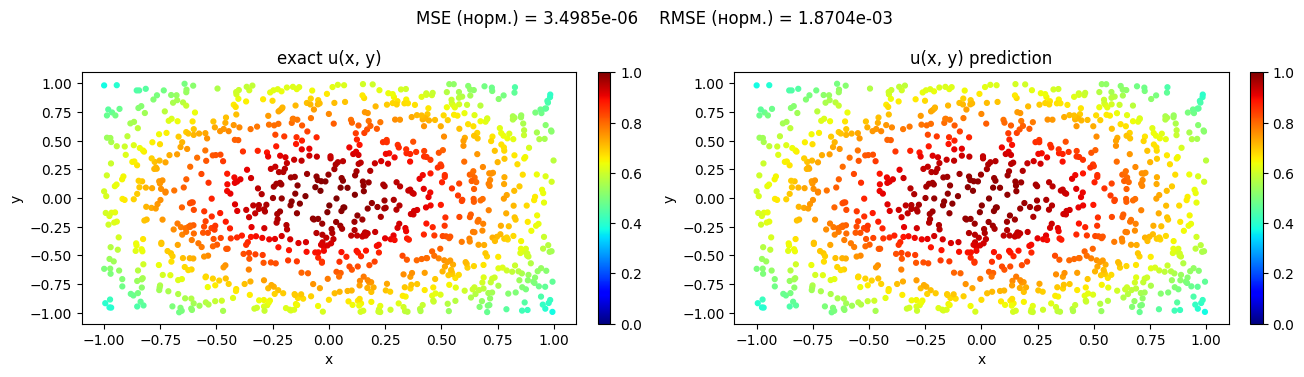

MSE в нормированных переменных : 3.498512e-06
RMSE в нормированных переменных: 1.870431e-03
MSE в исходных единицах        : 3.498512e-06


In [22]:
model.eval()
with torch.no_grad():
    u_pred = model_lbfgs(xy_train).cpu().numpy().reshape(u.shape)


mse_orig = float(np.mean((u_pred - u) ** 2))
rmse_orig=float(np.sqrt(mse_orig))
fig, axes = plt.subplots(1, 2, figsize=(13.2, 3.8))

im0 = axes[0].scatter(x, y, c=u, cmap="jet", s=12, vmin=0, vmax=1)
axes[0].set_title("exact u(x, y)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].scatter(x, y, c=u_pred, cmap="jet", s=12, vmin=0, vmax=1)
axes[1].set_title("u(x, y) prediction")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)



for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("auto")

fig.suptitle(f"MSE (норм.) = {mse_orig:.4e}    RMSE (норм.) = {rmse_orig:.4e}")
fig.tight_layout()
plt.show()

print(f"MSE в нормированных переменных : {mse_orig:.6e}")
print(f"RMSE в нормированных переменных: {rmse_orig:.6e}")
print(f"MSE в исходных единицах        : {mse_orig:.6e}")

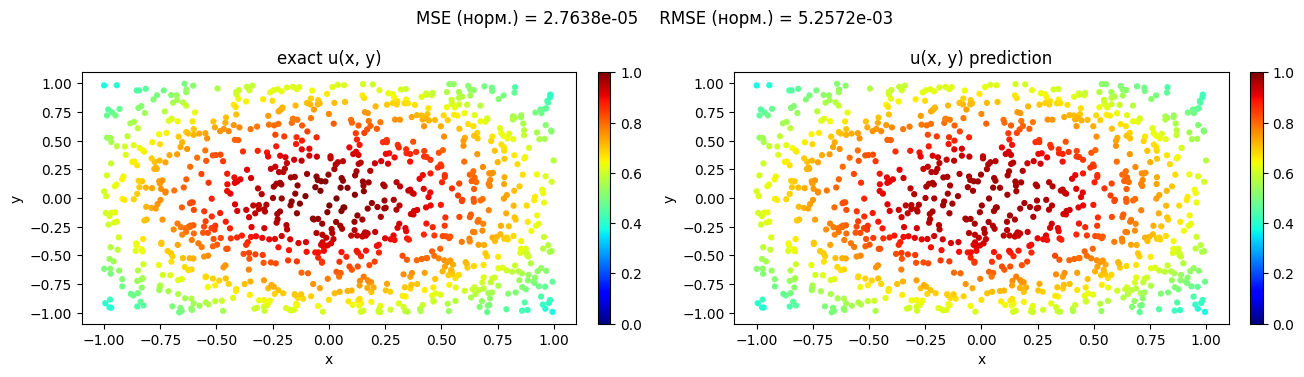

MSE в нормированных переменных : 2.763772e-05
RMSE в нормированных переменных: 5.257159e-03
MSE в исходных единицах        : 2.763772e-05


In [23]:
model.eval()
with torch.no_grad():
    u_pred = model_adam(xy_train).cpu().numpy().reshape(u.shape)


mse_orig = float(np.mean((u_pred - u) ** 2))
rmse_orig=float(np.sqrt(mse_orig))
fig, axes = plt.subplots(1, 2, figsize=(13.2, 3.8))

im0 = axes[0].scatter(x, y, c=u, cmap="jet", s=12, vmin=0, vmax=1)
axes[0].set_title("exact u(x, y)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].scatter(x, y, c=u_pred, cmap="jet", s=12, vmin=0, vmax=1)
axes[1].set_title("u(x, y) prediction")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)



for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("auto")

fig.suptitle(f"MSE (норм.) = {mse_orig:.4e}    RMSE (норм.) = {rmse_orig:.4e}")
fig.tight_layout()
plt.show()

print(f"MSE в нормированных переменных : {mse_orig:.6e}")
print(f"RMSE в нормированных переменных: {rmse_orig:.6e}")
print(f"MSE в исходных единицах        : {mse_orig:.6e}")

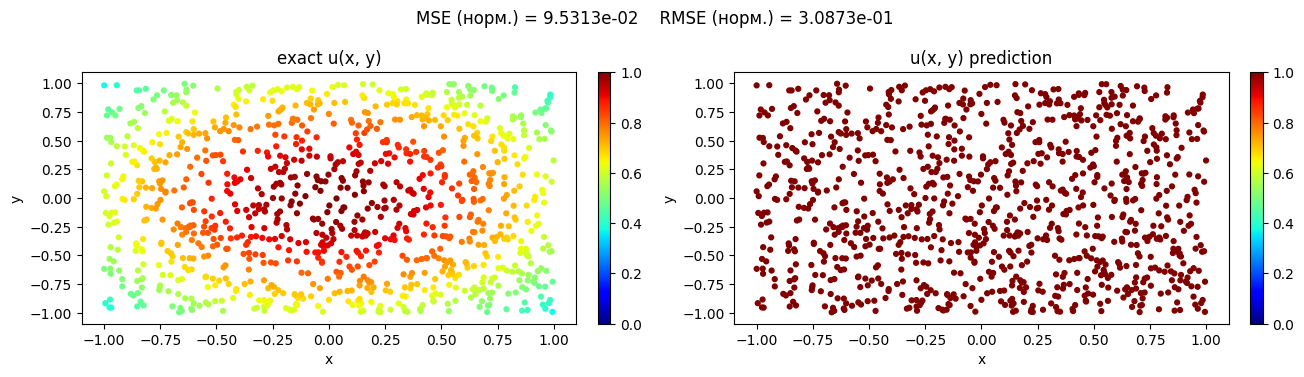

MSE в нормированных переменных : 9.531338e-02
RMSE в нормированных переменных: 3.087287e-01
MSE в исходных единицах        : 9.531338e-02


In [24]:
model.eval()
with torch.no_grad():
    u_pred = model_sgd(xy_train).cpu().numpy().reshape(u.shape)


mse_orig = float(np.mean((u_pred - u) ** 2))
rmse_orig=float(np.sqrt(mse_orig))
fig, axes = plt.subplots(1, 2, figsize=(13.2, 3.8))

im0 = axes[0].scatter(x, y, c=u, cmap="jet", s=12, vmin=0, vmax=1)
axes[0].set_title("exact u(x, y)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].scatter(x, y, c=u_pred, cmap="jet", s=12, vmin=0, vmax=1)
axes[1].set_title("u(x, y) prediction")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)



for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("auto")

fig.suptitle(f"MSE (норм.) = {mse_orig:.4e}    RMSE (норм.) = {rmse_orig:.4e}")
fig.tight_layout()
plt.show()

print(f"MSE в нормированных переменных : {mse_orig:.6e}")
print(f"RMSE в нормированных переменных: {rmse_orig:.6e}")
print(f"MSE в исходных единицах        : {mse_orig:.6e}")